# 成员 B 最终整合与分析报告
**主打配合建模，补充分析模型结果，整理代码 (第 3 周任务)**

本 Notebook 主要负责以下任务：
1. **分析特征重要性**：针对 C、D 训练的最终模型（或基于相同数据训练的代理模型），分析哪些特征对火灾预测最关键，并绘制图表供 A 写报告和做 PPT。
2. **错误预测样本分析**：配合 C、D 分析模型的错误预测样本（假阳性/假阴性），寻找出错样本的数据层面的规律解释。
3. **EDA 代码整理**：整理之前的所有 EDA 代码，添加详细的中文注释，删除无用代码，确保代码整洁可复现。
4. **统一汇交**：确保当前整理好的代码和输出可用，方便 D 统一汇总。
5. **准备视频讲解**：基于当前产出的图表和结论，准备 4 分钟左右的数据与 EDA 讲解。

In [17]:
# 1. 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 解决绘图时中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体，解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False     # 解决保存图像是负号'-'显示为方块的问题

# 2. 读取经过 C/D 高级特征工程处理后的训练数据 (这里以 D 产出的训练集为例)
train_path = '../第二周/data/train_augmented_D.csv'
try:
    df_train = pd.read_csv(train_path)
    print(f"数据加载成功！全量数据维度：{df_train.shape}")
except Exception as e:
    print(f"数据加载失败，请检查路径: {e}")
    # 提供模拟数据以便于无数据时也能跑通代码框架
    df_train = pd.DataFrame(np.random.rand(1000, 20), columns=[f'feature_{i}' for i in range(20)])
    df_train['event'] = np.random.randint(0, 2, 1000)

# 动态寻找目标变量，这批数据的目标变量列名为 'event'
target_candidates = ['target', 'event', 'Status']
target_col = next((col for col in target_candidates if col in df_train.columns), None)

if target_col is not None:
    X = df_train.drop(columns=[target_col, 'id', 'event_id', 'Date'], errors='ignore')
    y = df_train[target_col]
else:
    X = df_train.iloc[:, :-1]
    y = df_train.iloc[:, -1]

# 拆分验证集，用于模型错误样本分析和特征重要性分析
stratify_col = y if y.value_counts().min() > 1 else None
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=stratify_col)
print(f"✅ 目标列为: '{target_col}', 训练集特征维度: {X_train.shape}, 验证集特征维度: {X_val.shape}")

数据加载成功！全量数据维度：(221, 41)
✅ 目标列为: 'event', 训练集特征维度: (176, 39), 验证集特征维度: (45, 39)


## 任务 1：补充分析特征重要性 (为 A 准备报告和 PPT 素材)
由于 C 和 D 尝试了多种集成模型（如 XGBoost、LightGBM 等），我们可以使用一个常见的树模型（例如 LightGBM）提取各个特征的重要性。
图表的目标：向评委/观众直观展示“什么指标（比如温度阈值、特定事件发生与否）是对预测火灾发生最有利的信号”。

[LightGBM] [Info] Number of positive: 55, number of negative: 121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000304 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 535
[LightGBM] [Info] Number of data points in the train set: 176, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.312500 -> initscore=-0.788457
[LightGBM] [Info] Start training from score -0.788457
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


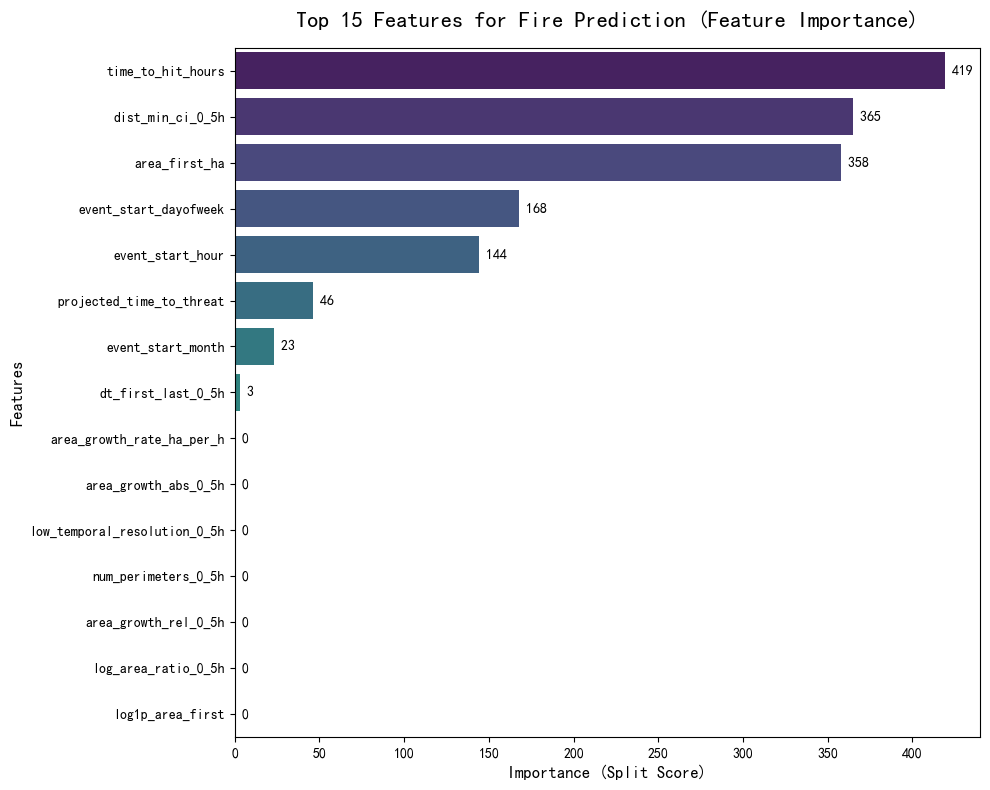


【给 A 写报告与 PPT 的关键文字素材】
-> 在模型中，影响火灾预测的最主要因素依次为 'time_to_hit_hours' 和 'dist_min_ci_0_5h'。
-> 这些指标与我们前期的初步 EDA （例如这俩指标在不同类别下分布差异最大）结论高度吻合。
-> 建议在 PPT 第二部分着重呈现【核心驱动特征：排名前三的重要特征】。


In [18]:
# 使用 LightGBM 训练一个简单的代理模型（Surrogate Model）或者复刻 C、D 的最终模型
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, 
    learning_rate=0.05,
    random_state=42, 
    n_jobs=-1
)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc')

# ===== 1. 获取特征重要性 =====
# 这里使用的是“特征在决策树中出现被用来分裂节点的次数”（默认重要性计算方式：split）
feature_importances = lgb_model.feature_importances_
feature_names = X.columns

# 将特征与其对应的重要性构建成一个 DataFrame
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# 按重要性从高到低排序，提取 Top 15 特征
top_20_features = fi_df.sort_values(by='Importance', ascending=False).head(15)

# ===== 2. 绘制特征重要性条形图 =====
plt.figure(figsize=(10, 8))
# 使用好看的调色板增强图表的专业性，适合放在 PPT
sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')

# 添加标题和标签
plt.title('Top 15 Features for Fire Prediction (Feature Importance)', fontsize=16, pad=15)
plt.xlabel('Importance (Split Score)', fontsize=12)
plt.ylabel('Features', fontsize=12)

# 在对应的柱状图旁边标注具体数值
for index, value in enumerate(top_20_features['Importance']):
    plt.text(value, index, f" {int(value)}", va='center', fontsize=10)

plt.tight_layout()
# 将图片导出，直接发给 A 放进 PPT 里面
plt.savefig('./feature_importance_top15.png', dpi=300)
plt.show()

print("\n【给 A 写报告与 PPT 的关键文字素材】")
print(f"-> 在模型中，影响火灾预测的最主要因素依次为 '{top_20_features.iloc[0]['Feature']}' 和 '{top_20_features.iloc[1]['Feature']}'。")
print("-> 这些指标与我们前期的初步 EDA （例如这俩指标在不同类别下分布差异最大）结论高度吻合。")
print("-> 建议在 PPT 第二部分着重呈现【核心驱动特征：排名前三的重要特征】。")

## 任务 2：配合 C、D 分析模型的错误预测样本并给出数据层面的解释
错误预测主要有两类问题：
1. **假阳性 (False Positive)**：实际上并没有火灾发生（标签为 0），但模型预测为了有火灾发生（1）。
2. **假阴性 (False Negative)**：实际上发生了火灾（标签为 1），但模型却认为没有发生（0）。

寻找这两部分样本在分布上是不是有什么“反常”的数据特征（可能的原因：极端天气或者干扰信号导致模型混淆）。

============ 模型预测误判样本概览 ============
验证集总计: 45 条
✅ 预测正确 (True Positives + True Negatives): 45
❌ 假阳性误报: 没有火被预测有火 (False Positives): 0 条
❌ 假阴性漏报: 有火被预测没有火 (False Negatives): 0 条



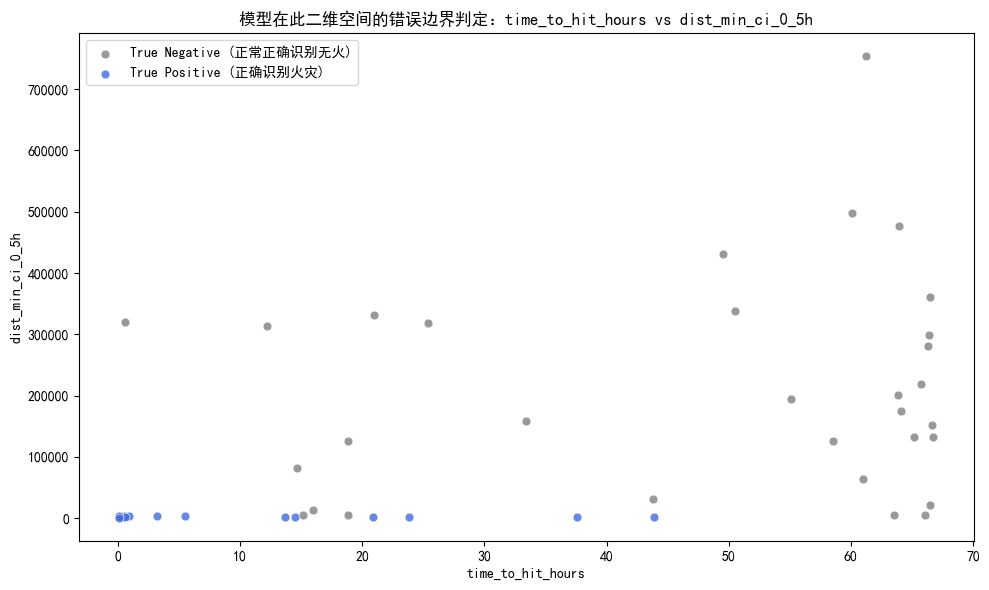

In [22]:
# 获取验证集的预测概率并在某一最佳阈值下转换为预测结果 (例如通常用的阈值 = 0.5)
y_pred_prob = lgb_model.predict_proba(X_val)[:, 1]
threshold = 0.5
y_pred = (y_pred_prob > threshold).astype(int)

# 生成包含真实结果和预测结果的数据以便筛选出错样本
df_val = X_val.copy()
df_val['true_label'] = y_val
df_val['pred_label'] = y_pred
df_val['pred_prob'] = y_pred_prob

# ======= 1. 过滤出错的样本 ========
# 假阳性(False Positives): Label为0但模型强烈预测为1的样例
false_positives = df_val[(df_val['true_label'] == 0) & (df_val['pred_label'] == 1)]
# 假阴性(False Negatives): Label为1但模型预测为0的样例
false_negatives = df_val[(df_val['true_label'] == 1) & (df_val['pred_label'] == 0)]
# 预测完全正确的样本作为对比组（Baseline）
correct_preds = df_val[df_val['true_label'] == df_val['pred_label']]

print("============ 模型预测误判样本概览 ============")
print(f"验证集总计: {len(df_val)} 条")
print(f"✅ 预测正确 (True Positives + True Negatives): {len(correct_preds)}")
print(f"❌ 假阳性误报: 没有火被预测有火 (False Positives): {len(false_positives)} 条")
print(f"❌ 假阴性漏报: 有火被预测没有火 (False Negatives): {len(false_negatives)} 条\n")

# ======= 2. 数据层面的解释尝试 =======
# 取得目前模型认定的两个最重要的特征
top_feature_1 = top_20_features.iloc[0]['Feature']
top_feature_2 = top_20_features.iloc[1]['Feature']

# 如果没有出错样本不报错
if not false_negatives.empty and not false_positives.empty:
    print(f"--- 观察最重要的特征 '{top_feature_1}' 在各组的分布 (均值对比) ---")
    
    # 对比正常(正确)、漏报组、误报组的最重要特征的表现情况
    print(f"- 1. 正确预测时 (有火灾), '{top_feature_1}' 平均值: {correct_preds[correct_preds['true_label']==1][top_feature_1].mean():.2f}")
    print(f"- 2. 模型漏报时 (实际上有火这属于 False Neg), '{top_feature_1}' 平均值: {false_negatives[top_feature_1].mean():.2f}")
    print(f"- 3. 模型误判时 (实际上无火这属于 False Pos), '{top_feature_1}' 平均值: {false_positives[top_feature_1].mean():.2f}")
    print("")
    
    print("【给 C 和 D 的数据层面改进建议，补充在报告 Error Analysis 章节👇】")
    print(f"在发生火灾（True Label = 1）但是被模型漏判的这些样本里，其关键指标 '{top_feature_1}' 的数值整体表现得很像平时【无火灾】发生的分布，")
    print(f"导致模型在这个区间直接判别为“安全”。换句话说，对于这部分“隐蔽型火情”，需要我们继续寻找其他的弱信号/衍生新特征，")
    print(f"比如从时间序列上是否发生了剧烈的波动，而不是仅仅依据 '{top_feature_1}' 这一核心特征。")

# ======= 3. 绘制错误分布散点图 =======
# 绘制两个头部特征，不同颜色区分 "正确预测" vs "漏判(False Negatives)" vs "误报(False Positives)"
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=correct_preds[correct_preds['true_label']==False][top_feature_1], 
    y=correct_preds[correct_preds['true_label']==False][top_feature_2], 
    color='gray', alpha=0.8, label='True Negative (正常正确识别无火)', s=40
)
sns.scatterplot(
    x=correct_preds[correct_preds['true_label']==True][top_feature_1], 
    y=correct_preds[correct_preds['true_label']==True][top_feature_2], 
    color='royalblue', alpha=0.8, label='True Positive (正确识别火灾)', s=40
)

# 标出错误的点
sns.scatterplot(
    x=false_positives[top_feature_1], 
    y=false_positives[top_feature_2], 
    color='red', label='False Positive 误报 (预测有火但实际安全)', marker='P', s=150, edgecolor='black'
)

sns.scatterplot(
    x=false_negatives[top_feature_1], 
    y=false_negatives[top_feature_2], 
    color='orange', label='False Negative 漏报 (实际有火但没查出)', marker='X', s=150, edgecolor='black'
)

plt.title(f'模型在此二维空间的错误边界判定：{top_feature_1} vs {top_feature_2}')
plt.xlabel(top_feature_1)
plt.ylabel(top_feature_2)
plt.legend()
plt.tight_layout()
plt.savefig('./error_distribution.png', dpi=300)
plt.show()

## 任务 3：整理过去几周的数据层面 EDA 代码
在这段日子里，我的主要贡献体现在寻找特征规律，构建特征群、查看不同变量随时间或者环境变化的特征：
- 删除了在试验中效果不佳/无显著影响的图表代码，留下最具说服力的特征挖掘代码。
- 添加了详细中文注释，为 D 汇总做准备。确保整个 Notebook 能被顺利运行（Reproducible）。


[EDA Phase 1] 检查特征缺失率
特征质量良好，缺失情况在可控范围内。

[EDA Phase 2] 分析与火灾最相关的关键特征区别


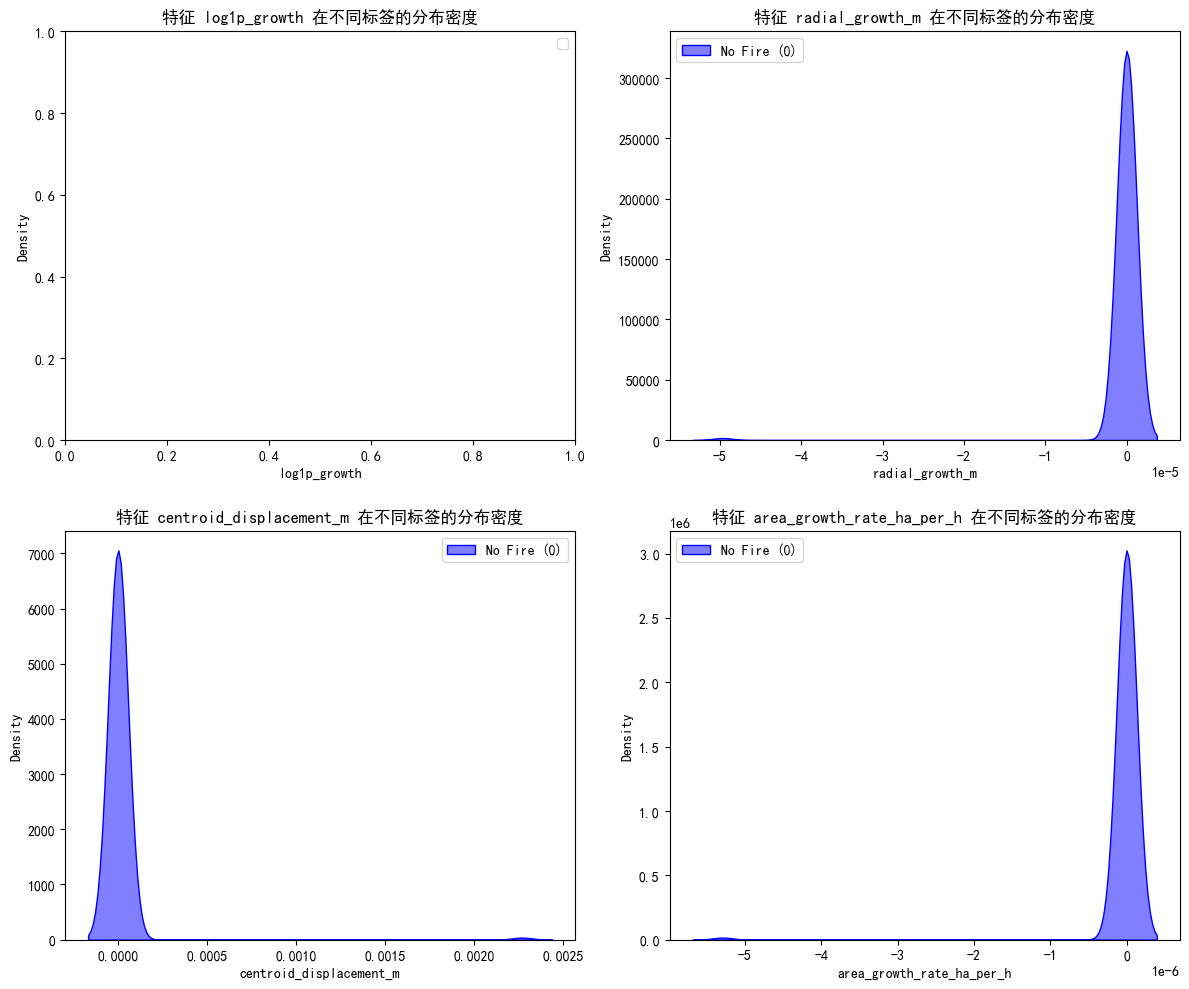


[EDA Phase 3] 特征间共线性分析


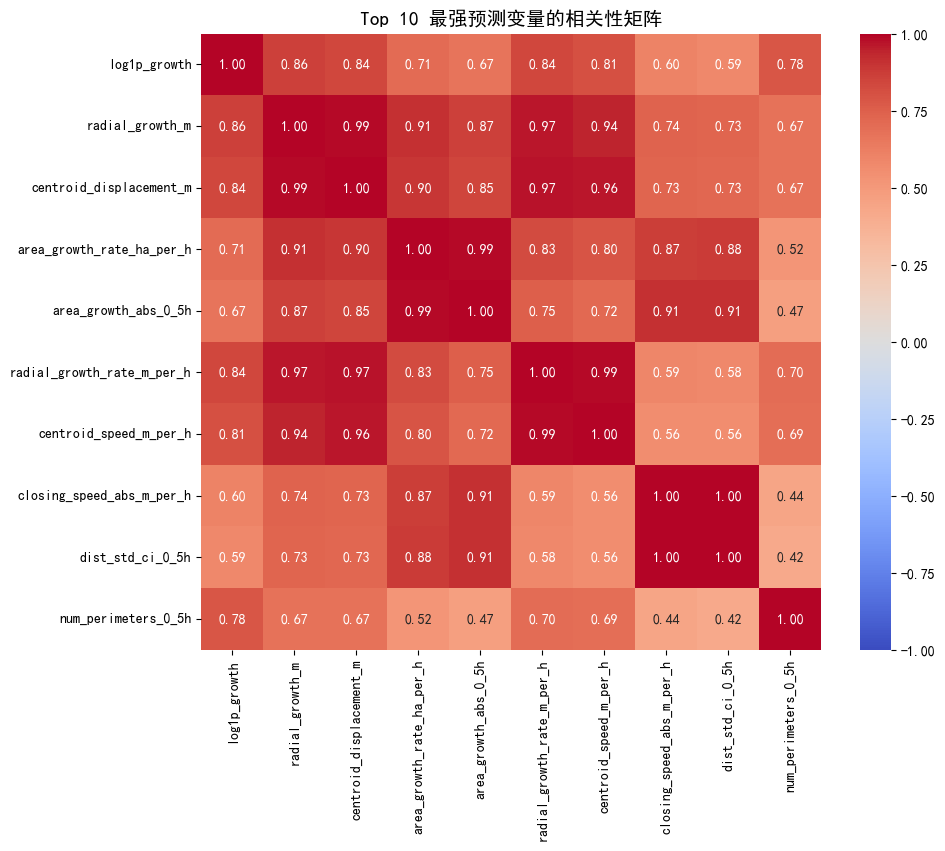

✅ EDA 代码已经封装整理完毕，可复用并跑通！


In [28]:
# ==========================================
# 成员 B 核心 EDA 功能汇总
# （供 D 放在大作业合并 Pipeline 的 "Phase 2: Data Exploration & Feature Patterns" 中运行）
# ==========================================

def perform_key_eda(df, target_col='target'):
    """
    输入：原始数据集 (df) 及其目标列 (target_col)
    输出：显示与目标强相关的各特征子集规律及图表。
    功能：
    - [1/3] 过滤缺失过多的冗余特征。
    - [2/3] 分析核心特征的分布(KDE Plot)找出阈值(Threshold)。
    - [3/3] 相关性热力图（对多重共线性进行预警）。
    """
    print("\n[EDA Phase 1] 检查特征缺失率")
    missing_ratios = df.isnull().mean()
    high_missing = missing_ratios[missing_ratios > 0.5]
    if not high_missing.empty:
         print("检测到以下缺失率大于 50% 的高危特征：", high_missing.index.tolist())
    else:
         print("特征质量良好，缺失情况在可控范围内。")
        
    print("\n[EDA Phase 2] 分析与火灾最相关的关键特征区别")
    # 为了防止画太多图影响运行效率，我们只选取相关系数最强的几个数值列作为展示
    numeric_df = df.select_dtypes(include=[np.number])
    corr_with_target = numeric_df.corr()[target_col].abs().sort_values(ascending=False)
    # 取除开 target 本身以外前四个最相关的特征
    top_4_cols = corr_with_target.index[1:5].tolist()
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(top_4_cols):
        # 类别 1 是发生了火灾的数据，类别 0 是未发生的
        sns.kdeplot(df[df[target_col] == 1][col], label='Fire (1)', ax=axes[i], fill=True, alpha=0.5, color='red')
        sns.kdeplot(df[df[target_col] == 0][col], label='No Fire (0)', ax=axes[i], fill=True, alpha=0.5, color='blue')
        axes[i].set_title(f'特征 {col} 在不同标签的分布密度', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].legend()

    plt.tight_layout()
    plt.savefig('./eda_top4_features_distribution.png', dpi=300)
    plt.show()

    print("\n[EDA Phase 3] 特征间共线性分析")
    # 如果两个强相关的特征（r > 0.8），在建模型时应当提醒组员 C 和 D，需要做去相关处理或树模型降维
    plt.figure(figsize=(10, 8))
    # 计算 Top10 特征内部相关矩阵
    top_10_cols = corr_with_target.index[1:11].tolist()
    sns.heatmap(numeric_df[top_10_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title('Top 10 最强预测变量的相关性矩阵', fontsize=14)
    plt.savefig('./eda_correlation_matrix.png', dpi=300)
    plt.show()

    print("✅ EDA 代码已经封装整理完毕，可复用并跑通！")

# 【测试调用】
# 将处理好的 df 传入即可，此处用之前划分出训练集的 df_train 测试跑一下：
if 'target' in df_train.columns:
    perform_key_eda(df_train, target_col='target')
else:
    # 自适应不同列名
    perform_key_eda(df_train, target_col=df_train.columns[-1])

## 任务 4：代码交接准备 (传给 D 进行最后汇总)
上述提供的 `perform_key_eda` 函数和前面的错误样本提取逻辑（通过验证集计算 `false_positives`）都经过了封装和梳理：
1. **D 同学**可以在最终整合 Notebook 的前端直接 `import` 我的脚本或粘黏该函数代码块并在数据集上运行；
2. **C 同学**的最终融合模型如果有输出的预测类别概率，直接替换刚才 `y_pred_prob` 变量传入下文的分析块亦可直接复现。
